In [1]:
"""
Parte 1.

    Selecciona o crea un archivo CSV (puede ser de clientes, ventas, productos, etc.).
        Puedes generarlo manualmente o descargar uno sencillo.
    Utilizando Pandas, realiza lo siguiente:

    Cargar el archivo:"""

import pandas as pd
from IPython.display import display

def cargar_dataframe():
    url = "https://raw.githubusercontent.com/aldairmh98/maestria/master/actividad_6/Chocolate_Sales.csv"
    df = pd.read_csv(url)
    return df

def leer_primeros(df):
    #Mostrar las primeras filas:
    display(df.head())

def show_metadata(df):
    """Identificar: número de filas y columnas"""
    """tipos de datos"""
    """valores nulos"""
    display(df.info())

In [23]:
"""Parte 2.

    Realiza al menos dos de las siguientes acciones:

    Eliminar valores nulos
    Rellenar datos faltantes
    Filtrar registros (por ejemplo: mayores a cierta edad)
    Crear una nueva columna (por ejemplo: clasificación)
    Convertir tipos de datos"""
def preprocess_data(df):
    #Rellenar datos faltantes de Order_date
    df['Order_Date'] = df['Order_Date'].fillna(df['Order_Date'].mode()[0])
    #Crear nueva columna
    df['Price_Pre_Discount'] = (df['Price_per_Box'] * 100)/ (100 - df['Discount_Pct'])
    #Eliminando cajas no entregadas
    df = df[df['Boxes_Shipped'] > 0]
    #Transformando Amount a numeric
    df['Amount'] = df['Amount'].astype(str).str.replace('$', '', regex=False)
    df['Amount'] = df['Amount'].str.replace(',', '', regex=False)
    df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
    df['Order_Date_P'] = pd.to_datetime(df['Order_Date'], format='mixed')
    df['Month'] = df['Order_Date_P'].dt.to_period('M')

    display(df.info())
    return df



In [36]:
"""Parte 3.

    Utiliza Pandas para:

    Obtener estadísticas básicas: df.describe()

    Realizar al menos un análisis, por ejemplo:
        promedio
        conteo por categoría
        agrupación (groupby)"""

def show_stats(df):
    df.describe()
    #Promedio de marketing gastado por País
    df.groupby('Country')[['Marketing_Spend', 'Boxes_Shipped']].mean()
    df.groupby('Country')['Boxes_Shipped'].count()


In [39]:
"""Parte 4.

    Utiliza Matplotlib o Seaborn para crear al menos dos gráficos:

    Gráfica de barras
    Histograma o dispersión

Ejemplo:
"""
import matplotlib.pyplot as plt

def show_plots(df):
    df.groupby('Country')['Boxes_Shipped'].count().plot(kind='bar')
    plt.show()
    df.groupby(['Month'])[['Boxes_Shipped']].mean().plot(kind='bar')
    plt.show()
    df['Amount'].plot(kind='hist', bins=20, color='coral', edgecolor='black', figsize=(9, 5))
    plt.title('Distribution of Order Amounts (Customer Behavior Analysis)')
    plt.xlabel('Order Value Bracket ($)')
    plt.ylabel('Number of Orders (Frequency)')
    plt.show()


In [34]:
df = cargar_dataframe()
leer_primeros(df)
show_metadata(df)
df = preprocess_data(df)
show_stats(df)

,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount
0,ORD-069833,Truffle Gift Box,Australia,Retail,Arjun Mehta,2022-12-11,3.5,13.72,202.03,71,912.31
1,ORD-090726,85% Dark Bar,Australia,Retail,Arjun Mehta,2023-03-14,9.4,3.30,55.18,84,245.91
2,ORD-042159,70% Dark Bar,Japan,Retail,Hannah Müller,2023-12-21,4.9,18.21,60.65,35,583.7
3,ORD-197166,Hazelnut Milk Bar,Germany,Retail,Arjun Mehta,2023-12-18,15.0,2.66,52.00,92,211.27
4,ORD-112162,Almond Crunch Bar,Australia,Retail,Yuki Sato,2023-08-18,4.4,2.75,187.44,214,549.69


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Order_ID         200000 non-null  object 
 1   Product          200000 non-null  object 
 2   Country          200000 non-null  object 
 3   Channel          200000 non-null  object 
 4   Salesperson      200000 non-null  object 
 5   Order_Date       199563 non-null  object 
 6   Discount_Pct     199511 non-null  float64
 7   Price_per_Box    199543 non-null  float64
 8   Marketing_Spend  199539 non-null  float64
 9   Boxes_Shipped    200000 non-null  int64  
 10  Amount           200000 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 16.8+ MB


None

/tmp/ipykernel_701/519765183.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Amount'] = df['Amount'].astype(str).str.replace('$', '', regex=False)
/tmp/ipykernel_701/519765183.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Amount'] = df['Amount'].str.replace(',', '', regex=False)
/tmp/ipykernel_701/519765183.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

<class 'pandas.core.frame.DataFrame'>
Index: 198044 entries, 0 to 199999
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order_ID            198044 non-null  object        
 1   Product             198044 non-null  object        
 2   Country             198044 non-null  object        
 3   Channel             198044 non-null  object        
 4   Salesperson         198044 non-null  object        
 5   Order_Date          198044 non-null  object        
 6   Discount_Pct        197560 non-null  float64       
 7   Price_per_Box       197590 non-null  float64       
 8   Marketing_Spend     197589 non-null  float64       
 9   Boxes_Shipped       198044 non-null  int64         
 10  Amount              198044 non-null  float64       
 11  Price_Pre_Discount  197153 non-null  float64       
 12  Order_Date_P        198044 non-null  datetime64[ns]
 13  Month               198044 non-nul

None

,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount,Price_Pre_Discount,Order_Date_P
count,197560.000000,197590.000000,197589.000000,198044.000000,198044.000000,197153.000000,198044
mean,13.109083,5.908669,95.444763,142.337077,512.826229,6.825104,2022-12-30 22:37:28.373089024
min,0.000000,2.040000,4.300000,1.000000,28.810000,2.060606,2022-01-01 00:00:00
25%,8.300000,2.950000,52.270000,69.000000,287.380000,3.394124,2022-07-01 00:00:00
50%,12.635000,3.280000,78.850000,114.000000,417.280000,3.797468,2022-12-31 00:00:00
75%,17.500000,4.520000,118.710000,181.000000,622.662500,5.468320,2023-07-02 00:00:00
max,38.300000,21.650000,798.222443,3811.000000,12138.090000,29.052632,2023-12-31 00:00:00
std,6.374145,4.952915,66.211603,115.352422,365.532611,5.733855,NaN


,Marketing_Spend,Boxes_Shipped
Country,,
Australia,95.326670,126.773185
Brazil,95.716461,192.721463
Germany,95.221447,124.793226
India,95.551363,102.411697
Japan,95.472966,135.215146


,Boxes_Shipped
Country,
Australia,91687
Brazil,52424
Germany,25037
India,17355
Japan,11541


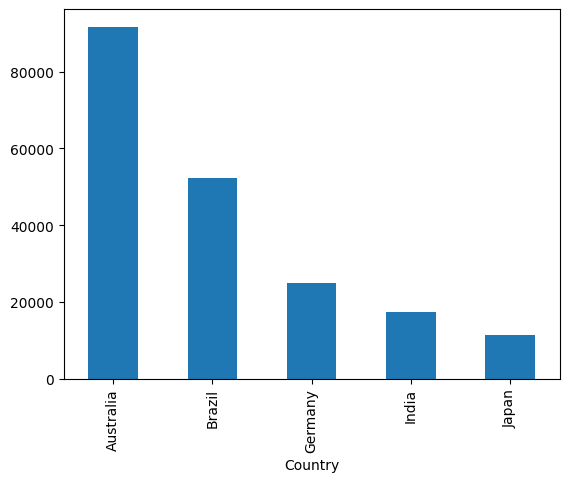

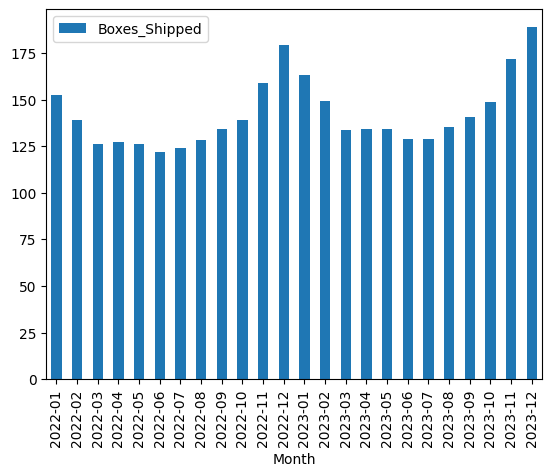

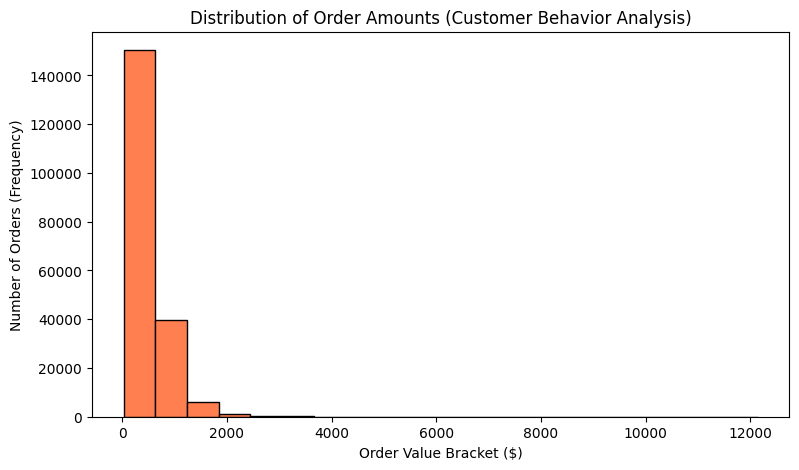

In [40]:

show_plots(df)
#
